send finns: True
rec finns : True
Lokal kopia av send: C:\Users\lundi\AppData\Local\Temp\pmu_local_work\send-station.xlsx
Lokal kopia av rec : C:\Users\lundi\AppData\Local\Temp\pmu_local_work\rec-station.xlsx
Output sparas i    : C:\Users\lundi\AppData\Local\Temp\pmu_local_work\overview_currents_voltages_angles_power


C:\Users\lundi\AppData\Local\Temp\ipykernel_155516\961675379.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_155516\961675379.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")


Antal synkade tidssteg: 7669
Start: 2025-12-11 15:25:02.469999
Slut : 2025-12-11 15:27:32.450000

SAMMANFATTNING:


,Phase,U_send_mean,U_rec_mean,I_send_mean,I_rec_mean,U_ang_send_mean_deg,U_ang_rec_mean_deg,I_ang_send_mean_deg,I_ang_rec_raw_mean_deg,I_ang_rec_corr_mean_deg,dU_mean_deg,dI_mean_deg,phi_send_mean_deg,phi_rec_mean_deg,cosphi_send_mean,cosphi_rec_mean,P_send_mean_W,P_rec_mean_W
0,L1,80883.253383,80496.368343,191.352329,189.581683,164.599535,163.688732,162.736856,-18.258586,161.741414,0.898770,0.984417,2.093927,2.179574,0.999271,0.999208,1.546604e+07,1.524867e+07
1,L2,80873.212155,80555.784209,201.844450,199.935422,44.619834,43.732696,40.568157,-140.393725,39.606275,0.875989,0.954564,4.287354,4.365929,0.997141,0.997023,1.627749e+07,1.605842e+07
2,L3,80929.100680,80685.289530,192.831843,190.632206,-75.398451,-76.308712,-81.443610,97.118344,-82.881656,0.898759,1.459783,6.290655,6.851677,0.993912,0.992758,1.551126e+07,1.527066e+07



FASFÖRSKJUTNING MELLAN L1, L2, L3:


,Signal,L1-L2 mean deg,L2-L3 mean deg,L3-L1 mean deg,L1 rel 0-360,L2 rel 0-360,L3 rel 0-360
0,U_send,119.977424,120.020442,120.002134,0.0,240.022576,120.002134
1,U_rec,119.954643,120.043213,120.002144,0.0,240.045357,120.002144
2,I_send,122.170851,122.023744,115.805405,0.0,237.829149,115.805405
3,I_rec_corr,122.140998,122.528963,115.330039,0.0,237.859002,115.330039


Sparat till: C:\Users\lundi\AppData\Local\Temp\pmu_local_work\overview_currents_voltages_angles_power


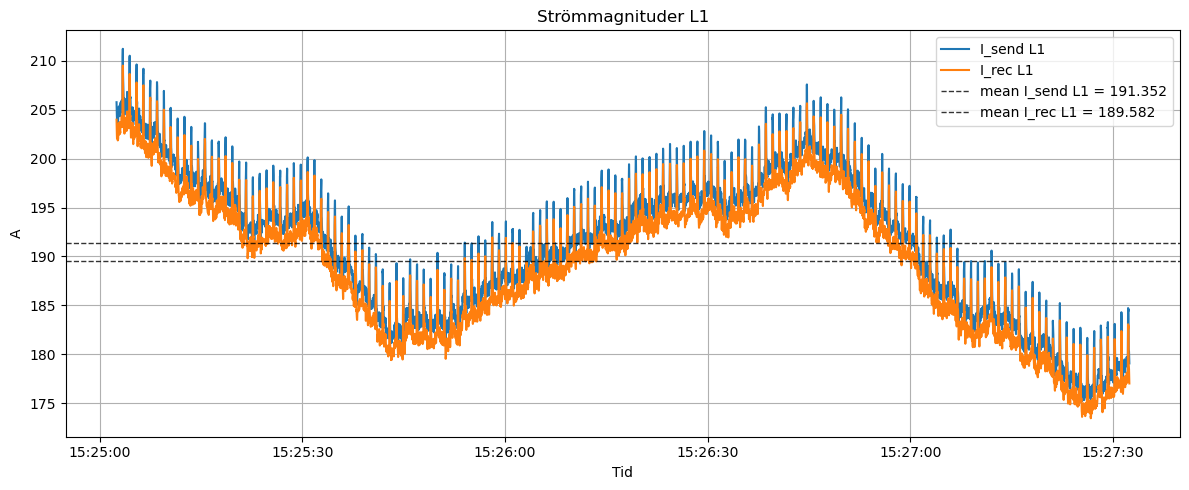

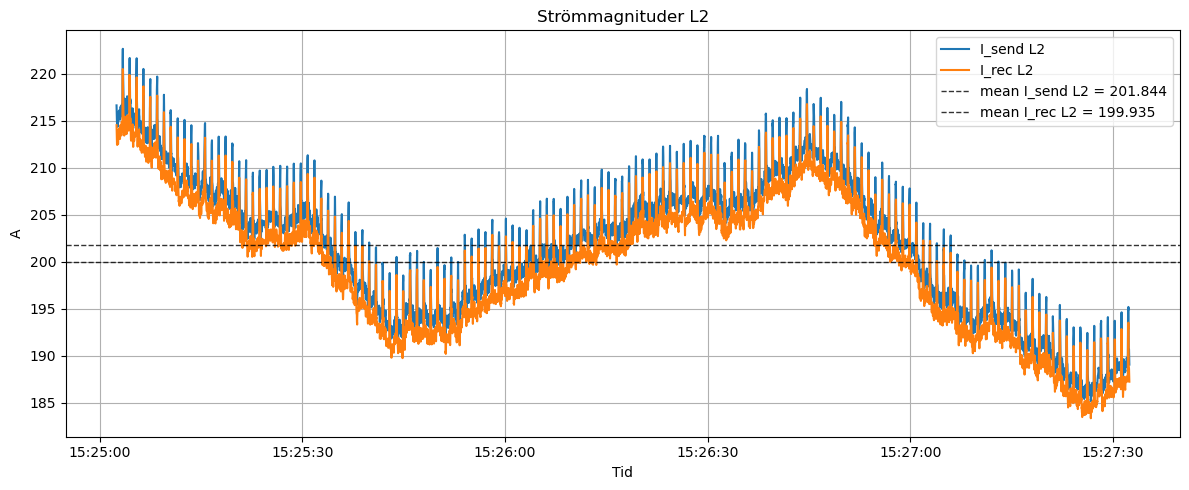

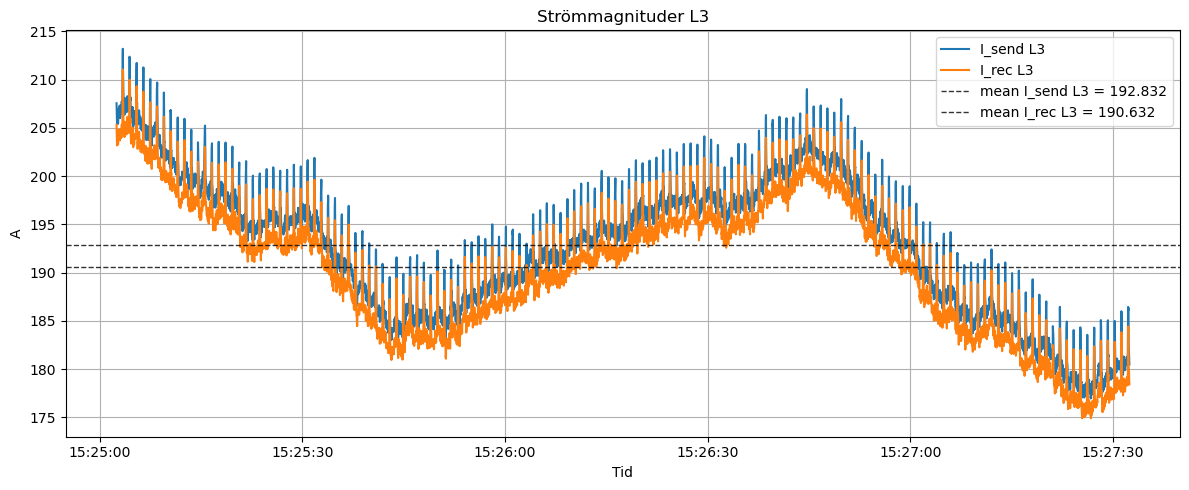

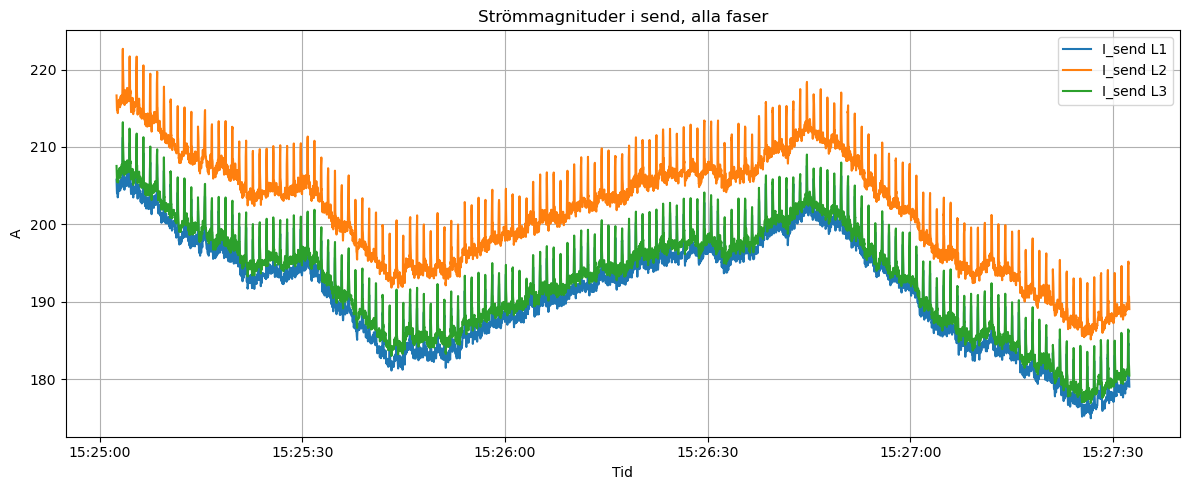

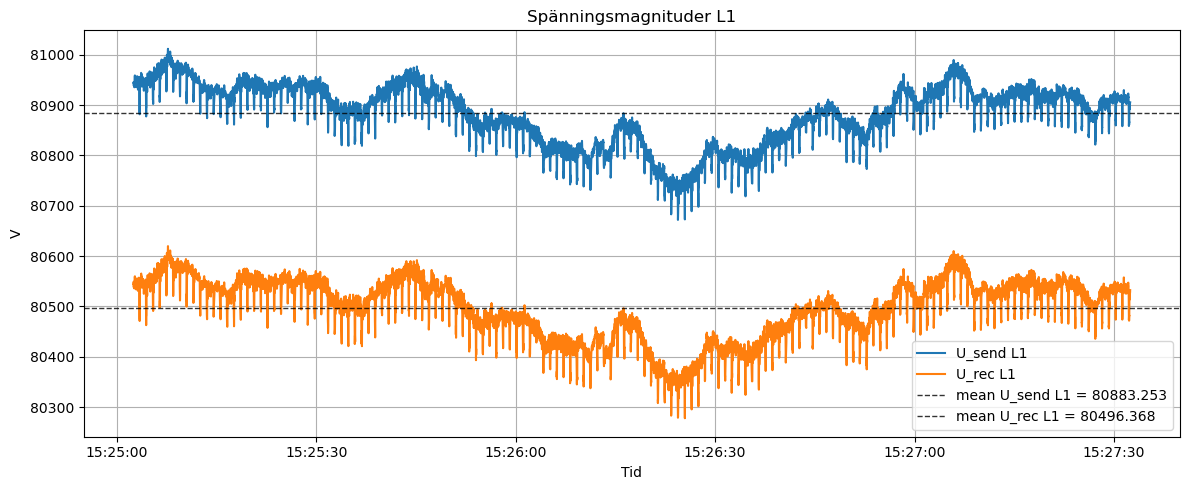

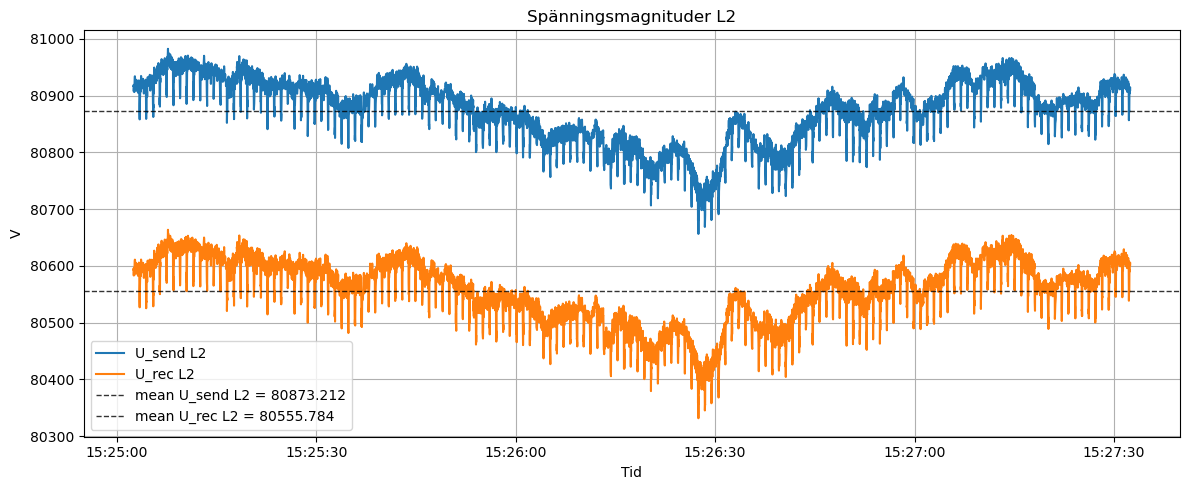

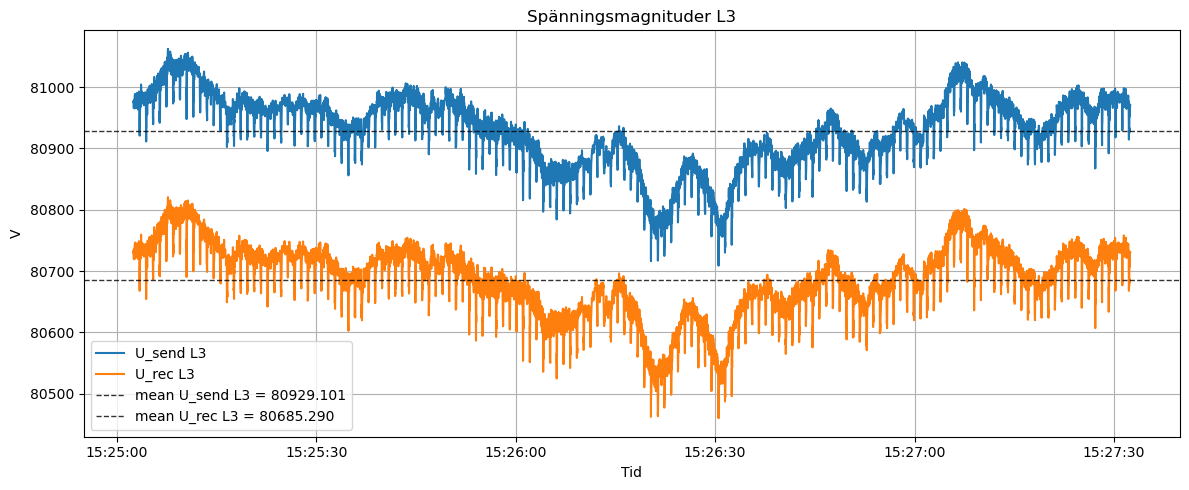

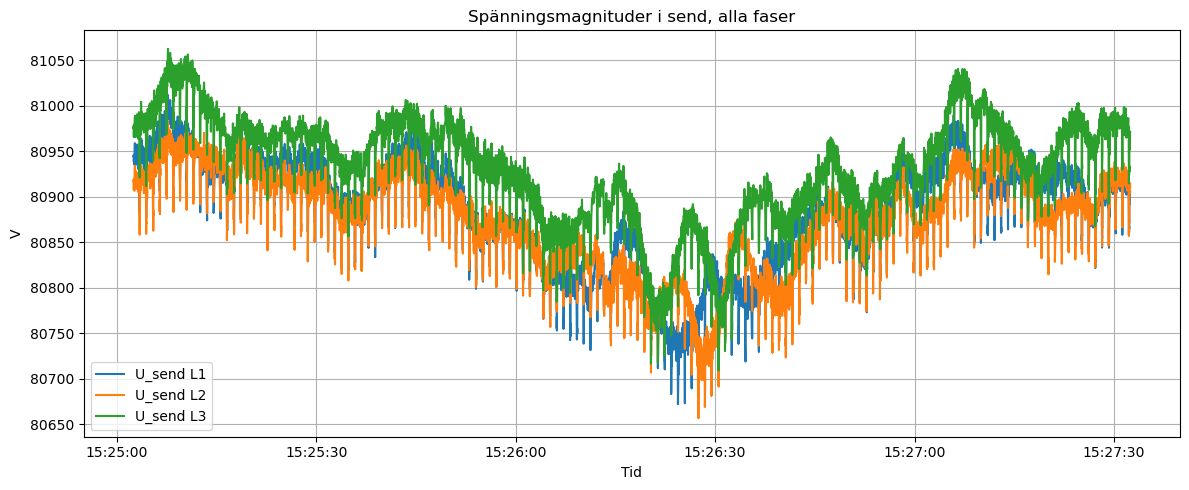

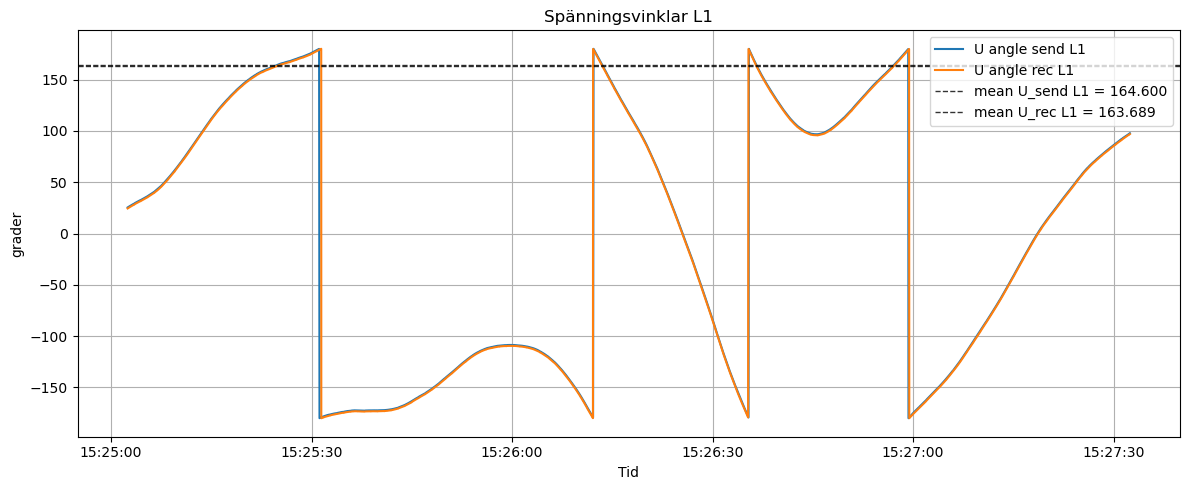

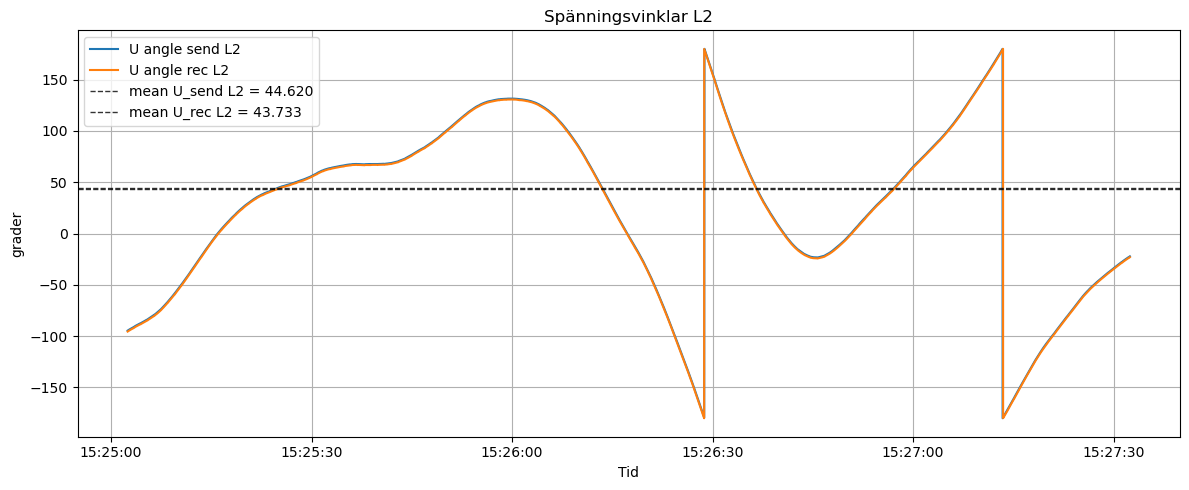

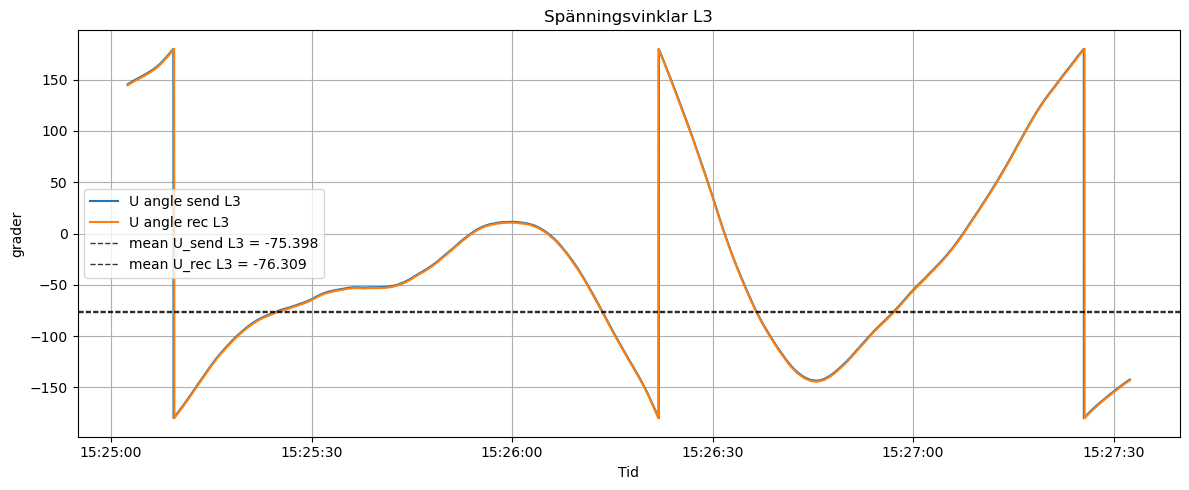

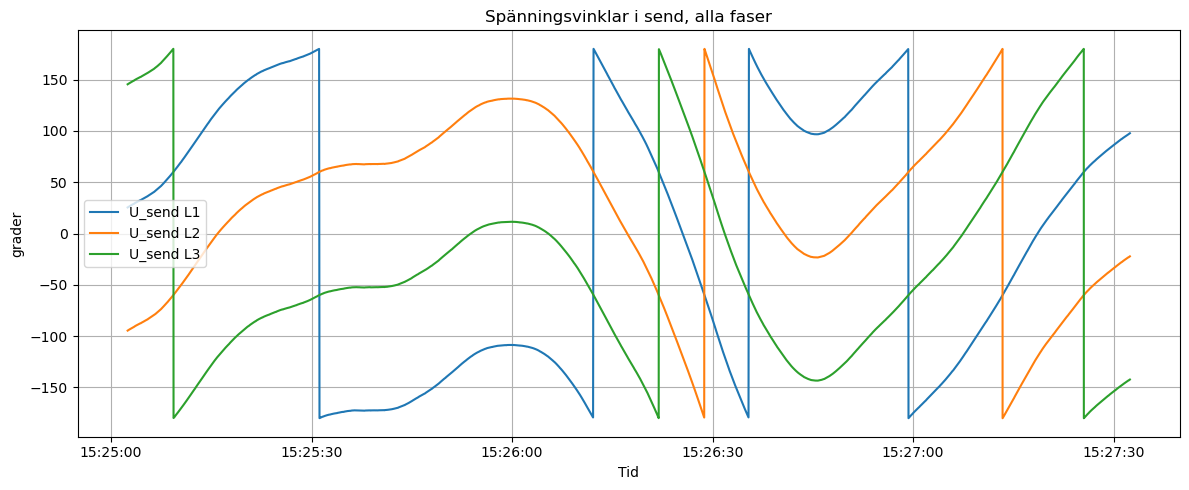

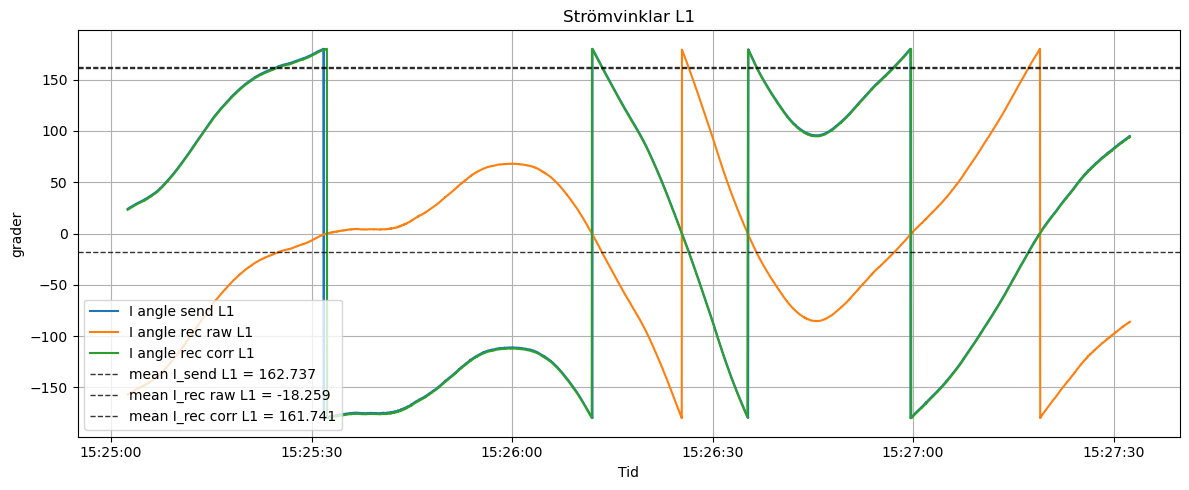

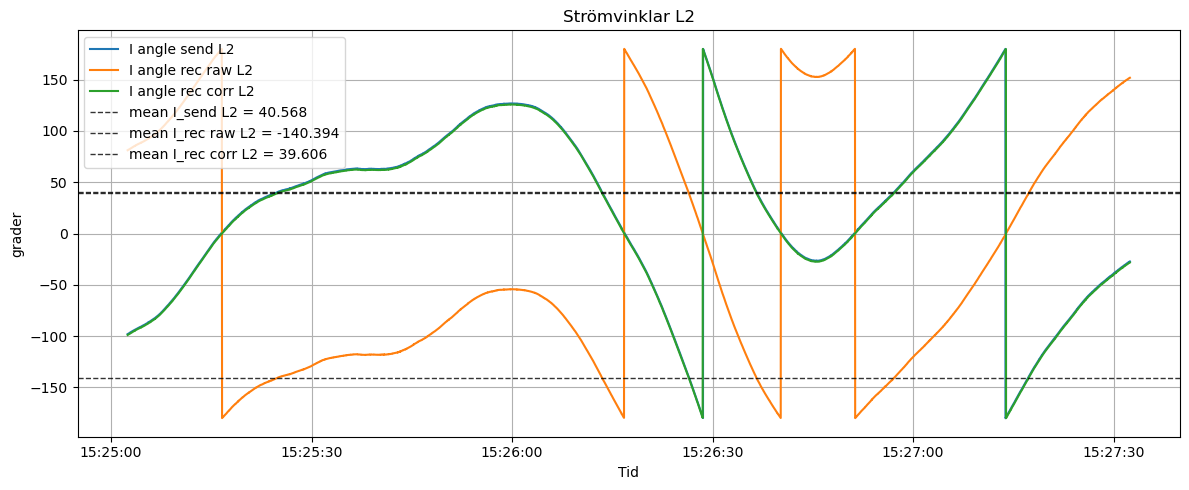

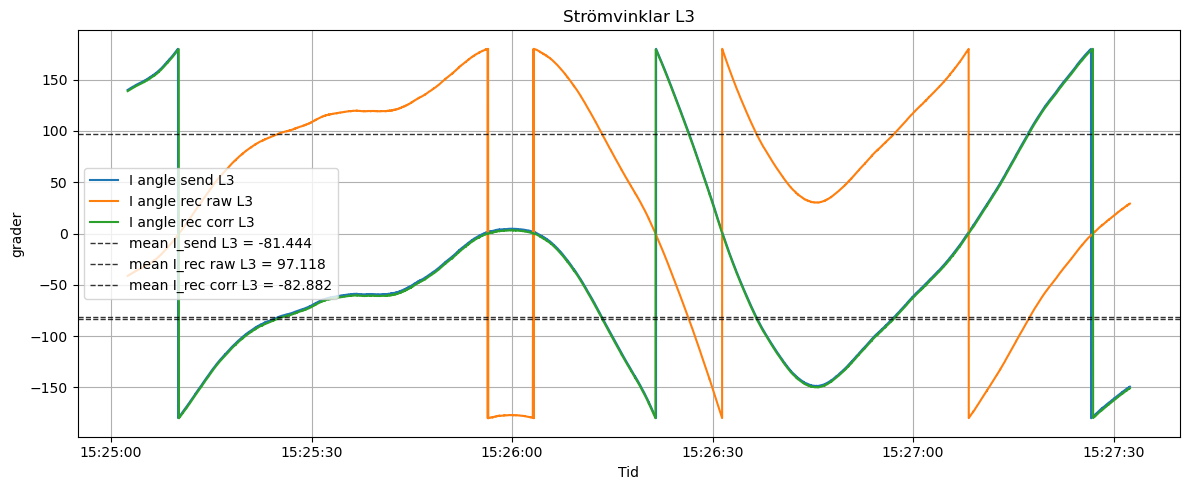

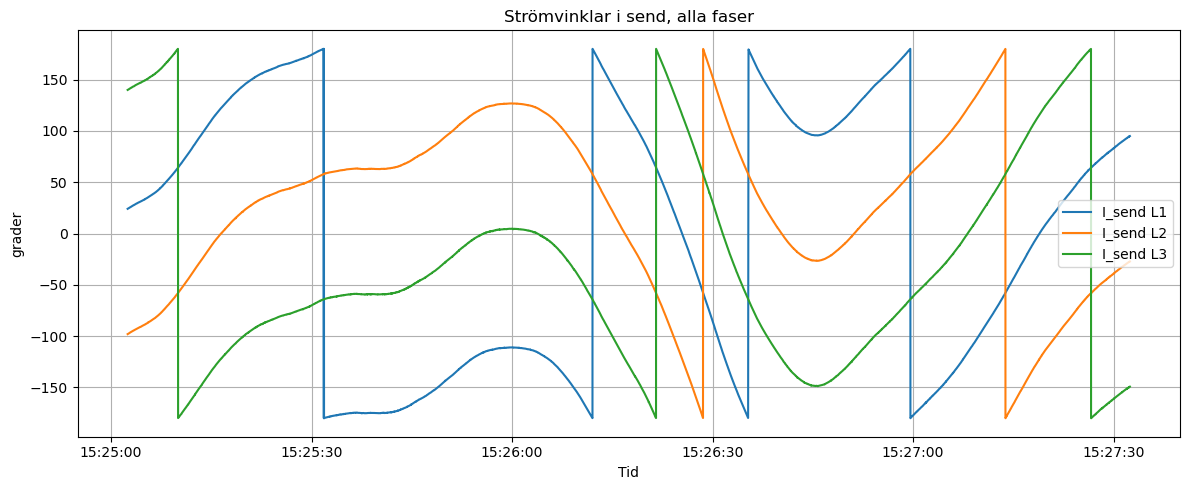

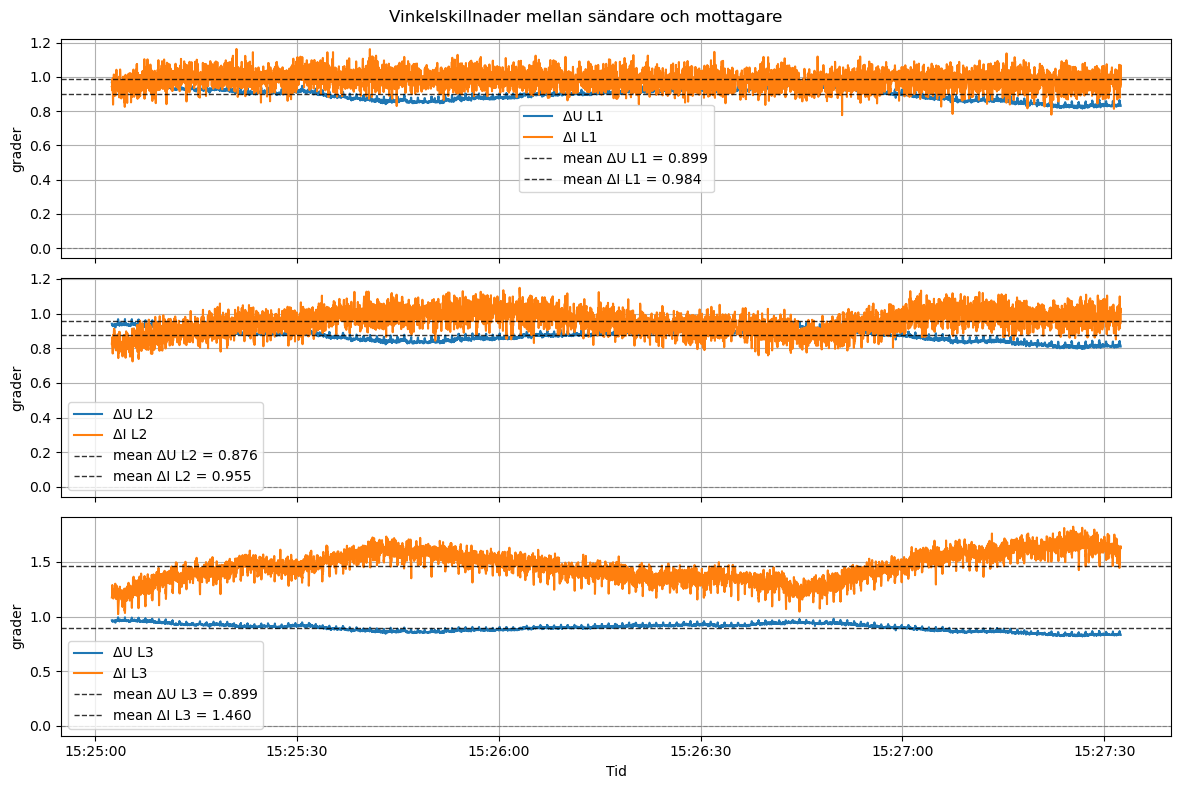

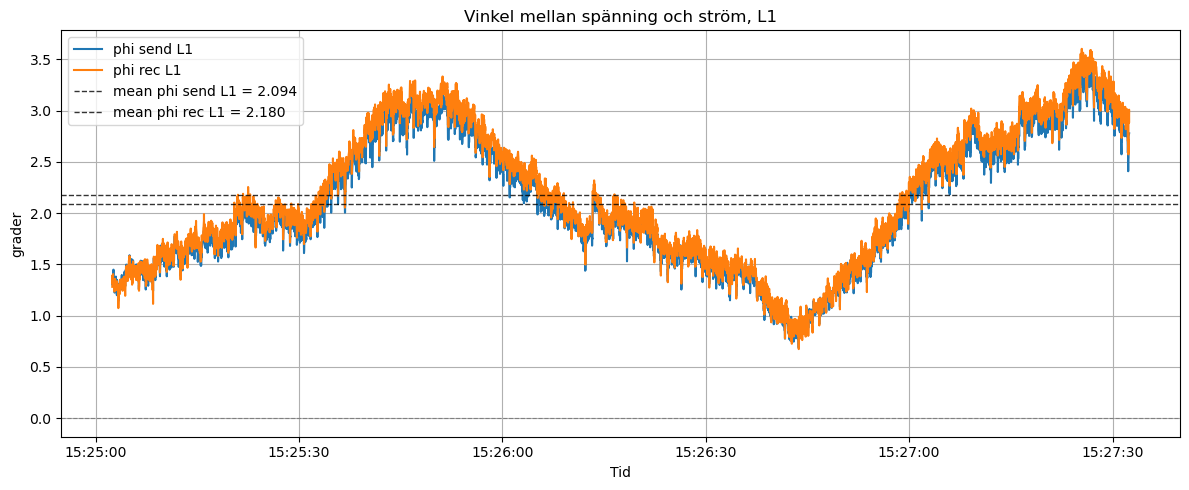

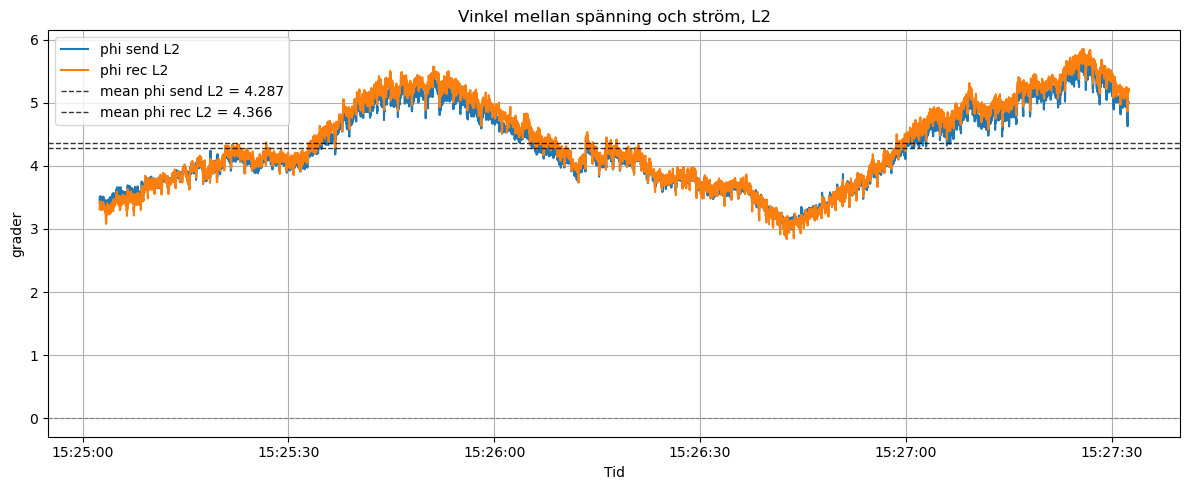

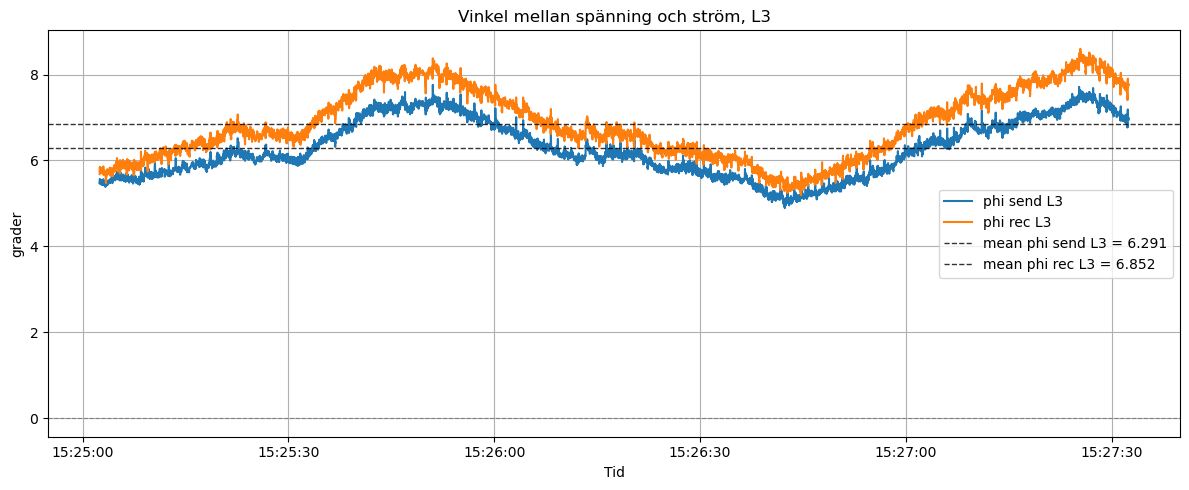

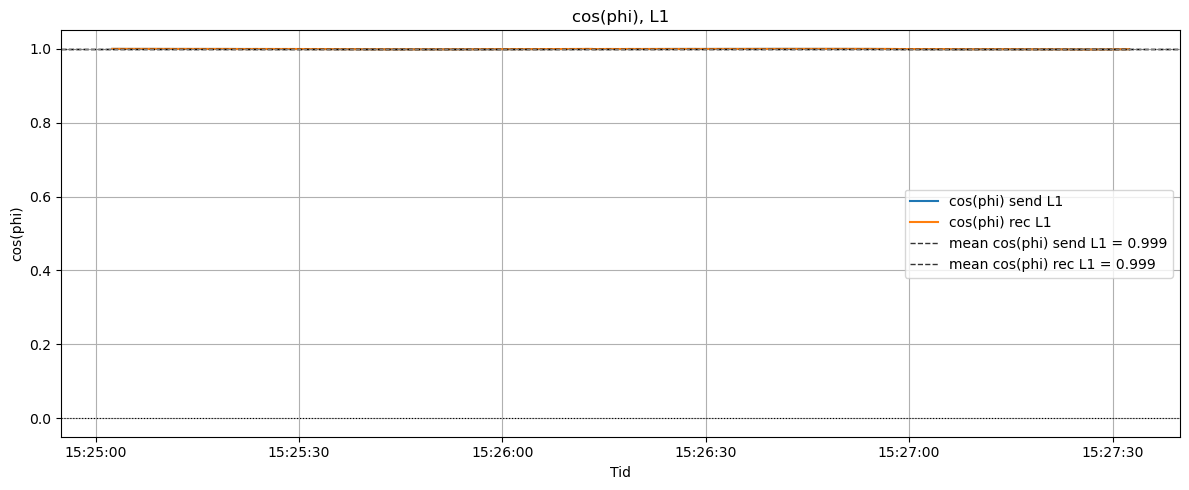

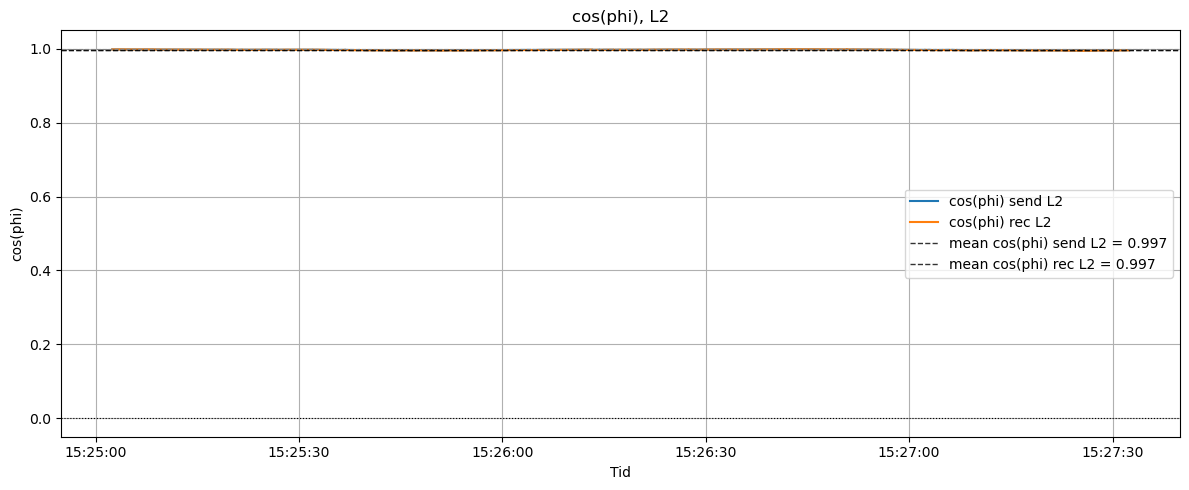

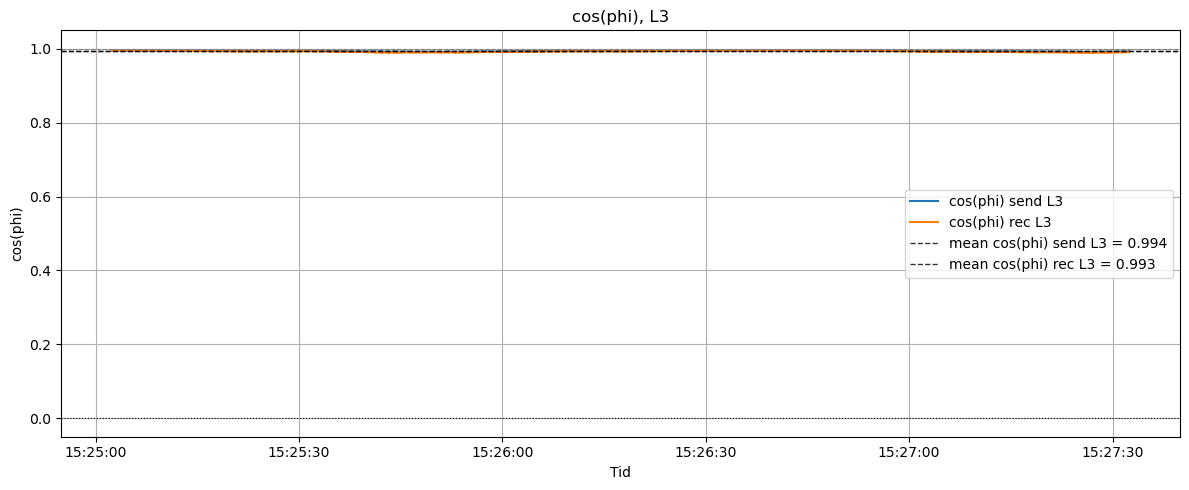

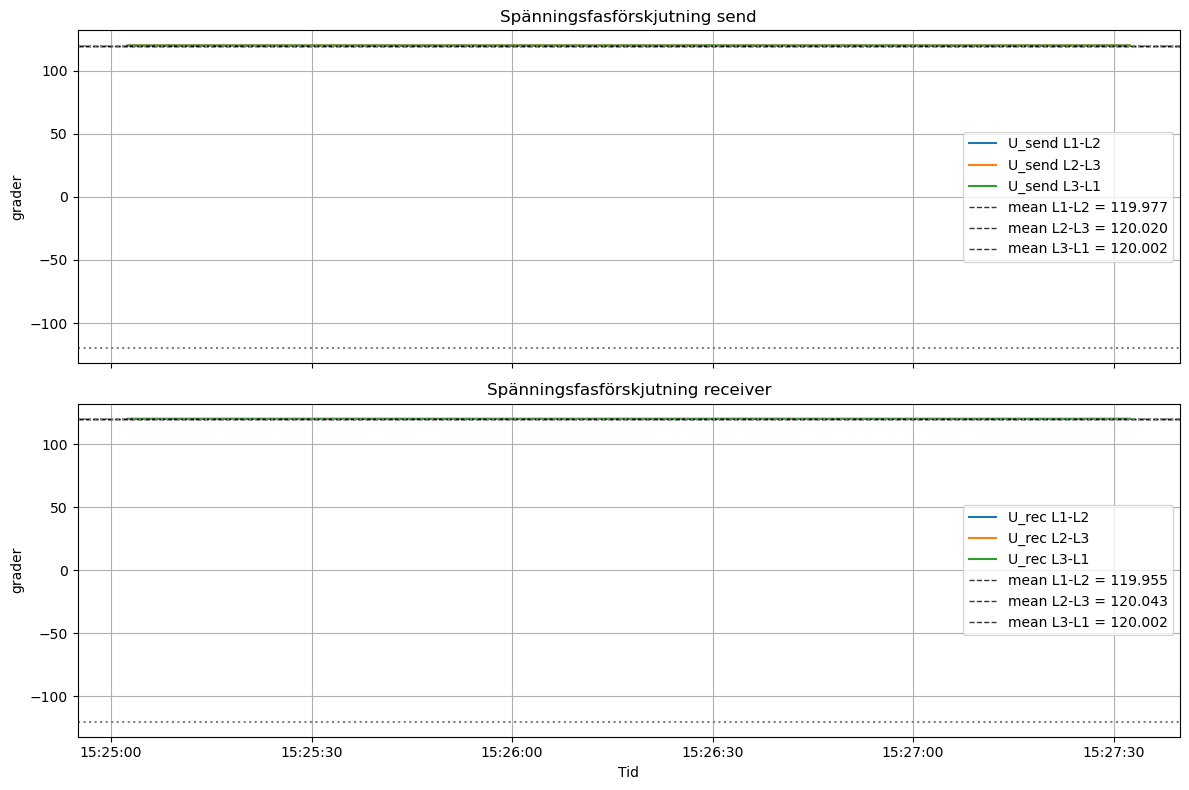

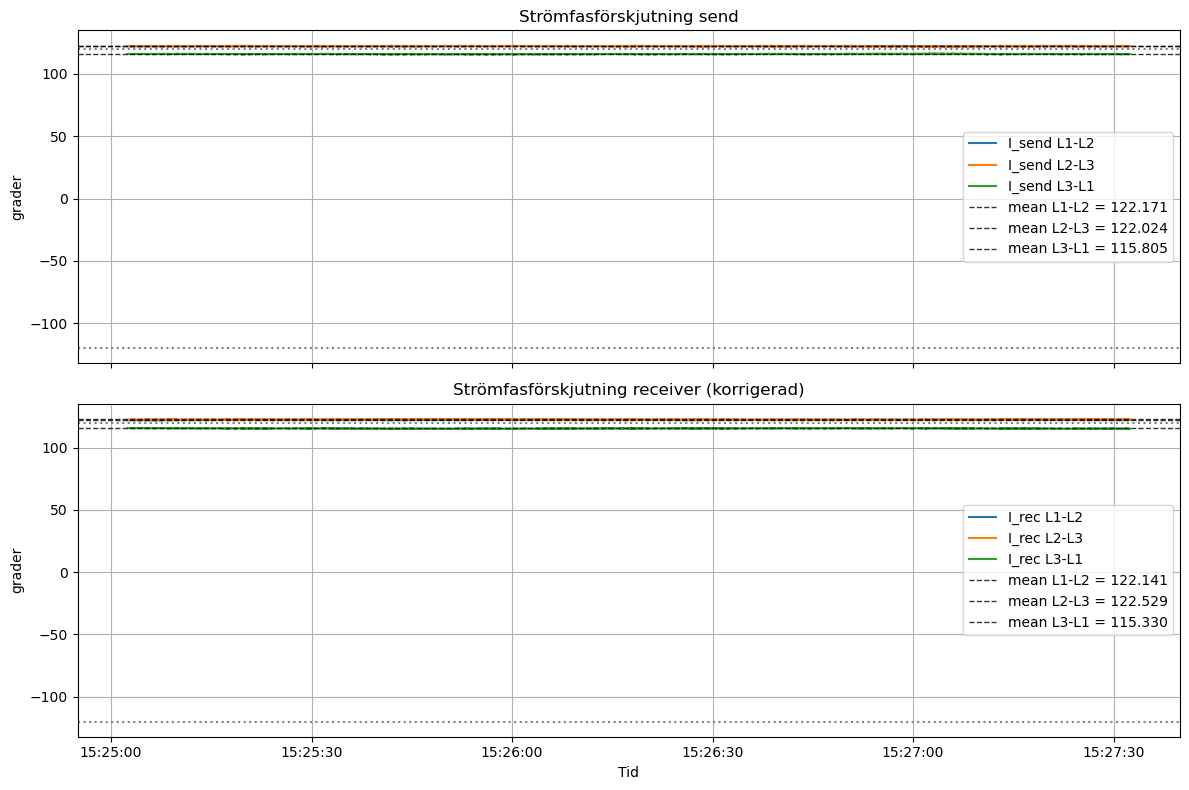

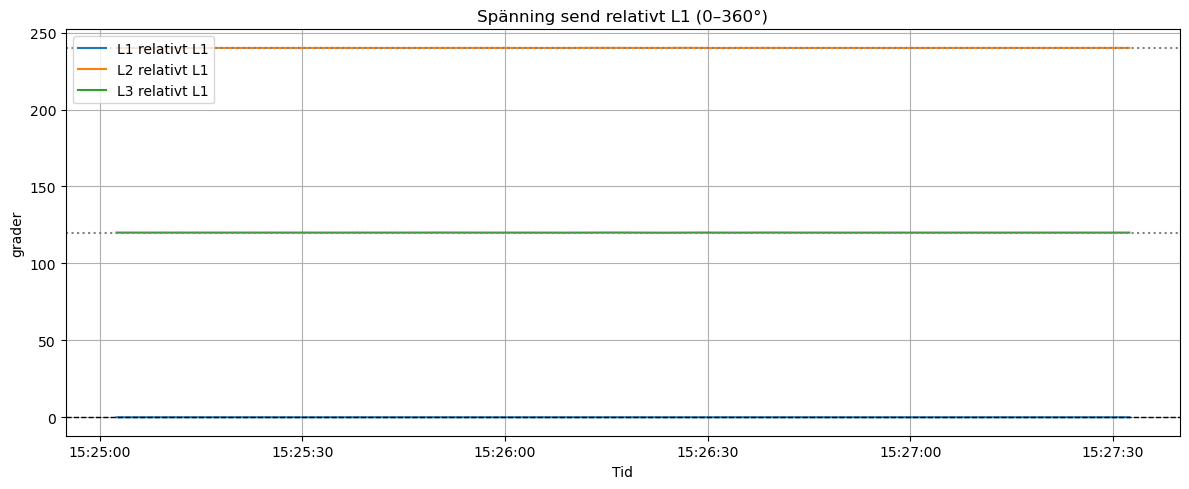

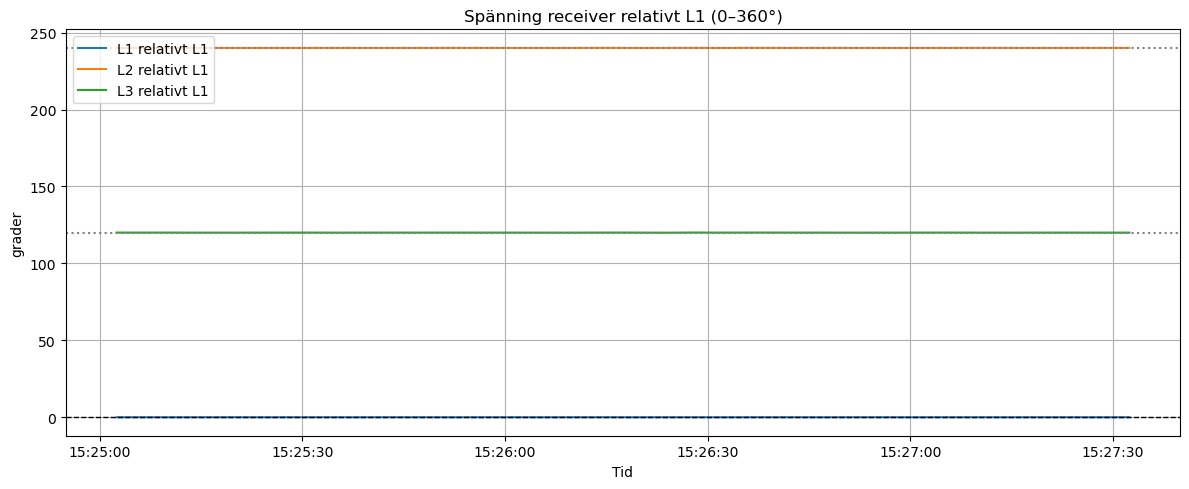

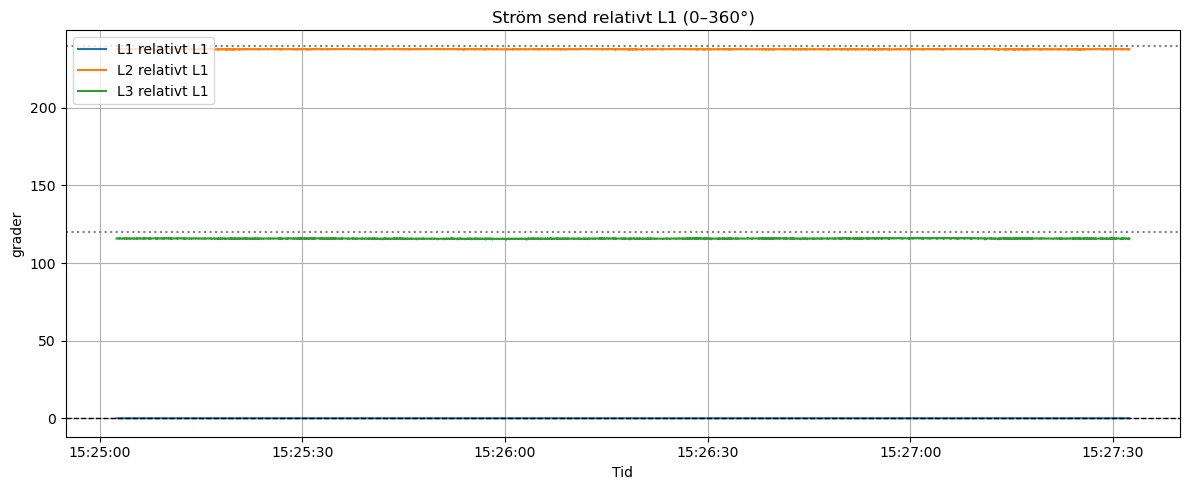

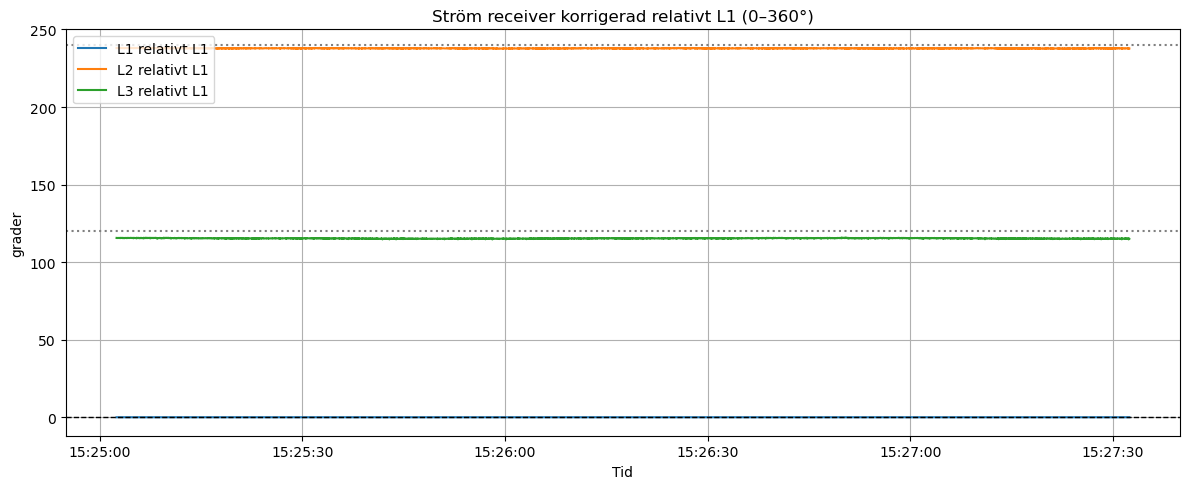

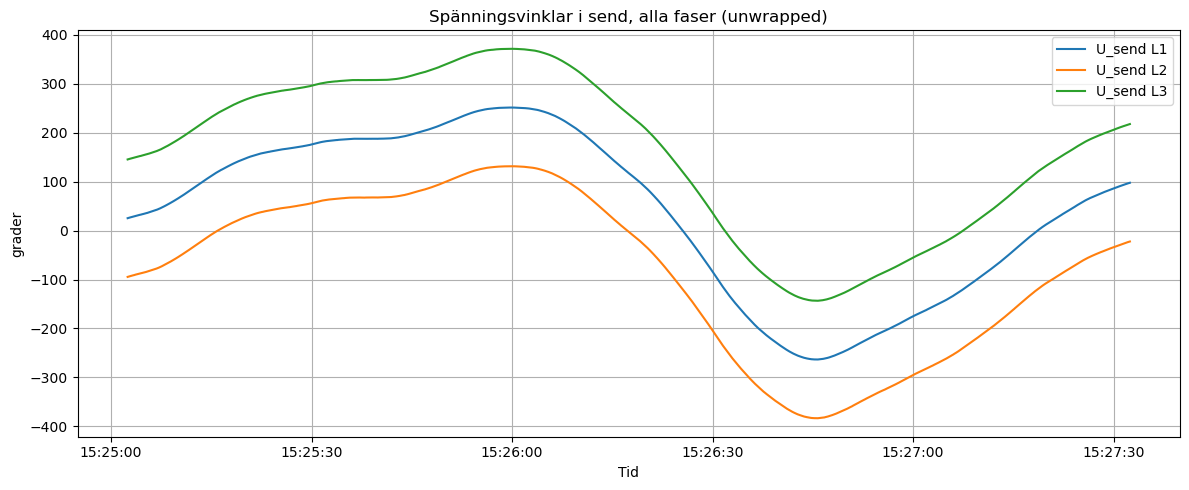

In [2]:
# ============================================================
# PLOTTA DET HANDLEDARNA VILL SE FÖRST:
# STRÖM, SPÄNNING, VINKLAR OCH EFFEKT
# ROBUST VERSION MED LOKAL KOPIA AV EXCEL-FILER
# ============================================================

import os
import re
import shutil
import tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# ORIGINALETS FILVÄGAR OCH BLADNAMN
# ============================================================

send_src = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_src  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_src.exists())
print("rec finns :", rec_src.exists())

# ============================================================
# SKAPA LOKAL ARBETSMAPP
# ============================================================

def safe_folder_name(name):
    return re.sub(r'[<>:"/\\|?*]', '_', name).strip().rstrip(".")

VERSION = safe_folder_name("overview_currents_voltages_angles_power")

local_root = Path(tempfile.gettempdir()) / "pmu_local_work"
local_root.mkdir(parents=True, exist_ok=True)

send_file = local_root / "send-station.xlsx"
rec_file  = local_root / "rec-station.xlsx"

# Kopiera filerna lokalt så att pandas slipper OneDrive-lås
# OBS: Om detta fortfarande ger fel, stäng Excel helt först.
shutil.copy2(send_src, send_file)
shutil.copy2(rec_src, rec_file)

output_dir = local_root / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

print("Lokal kopia av send:", send_file)
print("Lokal kopia av rec :", rec_file)
print("Output sparas i    :", output_dir)

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def to_360(angle_deg):
    return angle_deg % 360.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def add_mean_line(ax, y, label_prefix="mean", circular=False, color="black"):
    if circular:
        mean_val = circular_mean_deg(y)
    else:
        mean_val = np.nanmean(y)
    ax.axhline(mean_val, linestyle="--", linewidth=1.0, color=color, alpha=0.8,
               label=f"{label_prefix} = {mean_val:.3f}")
    return mean_val

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None, engine="openpyxl")
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None, engine="openpyxl")
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

# ============================================================
# 1. LÄS OCH MAPPA DATA
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

send = read_data_table_safe(send_file, dataS_sheet)
rec  = read_data_table_safe(rec_file, dataR_sheet)

send = send.merge(keyS, on="ID", how="inner")
rec  = rec.merge(keyR, on="ID", how="inner")

wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

wideS = wideS.add_suffix("_S").sort_index()
wideR = wideR.add_suffix("_R").sort_index()

df_joined = wideS.join(wideR, how="inner").copy()

required_cols = []
for ph in ["L1", "L2", "L3"]:
    required_cols += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
        f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in required_cols if c not in df_joined.columns]
if missing:
    raise ValueError(f"Saknade kolumner: {missing}")

df_joined = df_joined.dropna(subset=required_cols).copy()

# filtrera bort orimliga vinkelvärden
angle_cols = [c for c in df_joined.columns if "ANG" in c]
for c in angle_cols:
    df_joined = df_joined[(df_joined[c] >= -180) & (df_joined[c] <= 180)]

print("Antal synkade tidssteg:", len(df_joined))
print("Start:", df_joined.index.min())
print("Slut :", df_joined.index.max())

# ============================================================
# 2. BYGG TABELL MED STRÖM/SPÄNNING/VINKLAR/EFFEKT
# ============================================================

out = pd.DataFrame(index=df_joined.index)

for ph in ["L1", "L2", "L3"]:
    out[f"U_mag_S_{ph}"] = df_joined[f"U{ph}MAG_S"]
    out[f"U_mag_R_{ph}"] = df_joined[f"U{ph}MAG_R"]
    out[f"I_mag_S_{ph}"] = df_joined[f"I{ph}MAG_S"]
    out[f"I_mag_R_{ph}"] = df_joined[f"I{ph}MAG_R"]

    out[f"U_ang_S_{ph}"] = df_joined[f"U{ph}ANG_S"]
    out[f"U_ang_R_{ph}"] = df_joined[f"U{ph}ANG_R"]
    out[f"I_ang_S_{ph}"] = df_joined[f"I{ph}ANG_S"]
    out[f"I_ang_R_raw_{ph}"] = df_joined[f"I{ph}ANG_R"]

    # korrigera mottagarström med 180°
    out[f"I_ang_R_corr_{ph}"] = wrap_angle_deg(df_joined[f"I{ph}ANG_R"] + 180.0)

    Vs = complex_from_mag_ang(out[f"U_mag_S_{ph}"], out[f"U_ang_S_{ph}"])
    Vr = complex_from_mag_ang(out[f"U_mag_R_{ph}"], out[f"U_ang_R_{ph}"])

    Is = complex_from_mag_ang(out[f"I_mag_S_{ph}"], out[f"I_ang_S_{ph}"])
    Ir_corr = complex_from_mag_ang(out[f"I_mag_R_{ph}"], out[f"I_ang_R_corr_{ph}"])

    out[f"P_send_{ph}"] = np.real(Vs * np.conj(Is))
    out[f"P_rec_{ph}"]  = np.real(Vr * np.conj(Ir_corr))

    out[f"dU_{ph}"] = wrap_angle_deg(out[f"U_ang_S_{ph}"] - out[f"U_ang_R_{ph}"])
    out[f"dI_{ph}"] = wrap_angle_deg(out[f"I_ang_S_{ph}"] - out[f"I_ang_R_corr_{ph}"])

    out[f"phi_send_deg_{ph}"] = wrap_angle_deg(out[f"U_ang_S_{ph}"] - out[f"I_ang_S_{ph}"])
    out[f"phi_rec_deg_{ph}"] = wrap_angle_deg(out[f"U_ang_R_{ph}"] - out[f"I_ang_R_corr_{ph}"])

    out[f"cosphi_send_{ph}"] = np.cos(np.deg2rad(out[f"phi_send_deg_{ph}"]))
    out[f"cosphi_rec_{ph}"]  = np.cos(np.deg2rad(out[f"phi_rec_deg_{ph}"]))

out["P_total_send"] = out[[f"P_send_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)
out["P_total_rec"]  = out[[f"P_rec_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)

# ============================================================
# 3. FASFÖRSKJUTNING MELLAN L1, L2, L3
# ============================================================

out["dU_send_L1_L2"] = wrap_angle_deg(out["U_ang_S_L1"] - out["U_ang_S_L2"])
out["dU_send_L2_L3"] = wrap_angle_deg(out["U_ang_S_L2"] - out["U_ang_S_L3"])
out["dU_send_L3_L1"] = wrap_angle_deg(out["U_ang_S_L3"] - out["U_ang_S_L1"])

out["dU_rec_L1_L2"] = wrap_angle_deg(out["U_ang_R_L1"] - out["U_ang_R_L2"])
out["dU_rec_L2_L3"] = wrap_angle_deg(out["U_ang_R_L2"] - out["U_ang_R_L3"])
out["dU_rec_L3_L1"] = wrap_angle_deg(out["U_ang_R_L3"] - out["U_ang_R_L1"])

out["dI_send_L1_L2"] = wrap_angle_deg(out["I_ang_S_L1"] - out["I_ang_S_L2"])
out["dI_send_L2_L3"] = wrap_angle_deg(out["I_ang_S_L2"] - out["I_ang_S_L3"])
out["dI_send_L3_L1"] = wrap_angle_deg(out["I_ang_S_L3"] - out["I_ang_S_L1"])

out["dI_rec_L1_L2"] = wrap_angle_deg(out["I_ang_R_corr_L1"] - out["I_ang_R_corr_L2"])
out["dI_rec_L2_L3"] = wrap_angle_deg(out["I_ang_R_corr_L2"] - out["I_ang_R_corr_L3"])
out["dI_rec_L3_L1"] = wrap_angle_deg(out["I_ang_R_corr_L3"] - out["I_ang_R_corr_L1"])

for prefix in ["U_ang_S", "U_ang_R", "I_ang_S", "I_ang_R_corr"]:
    L1 = out[f"{prefix}_L1"]
    L2 = out[f"{prefix}_L2"]
    L3 = out[f"{prefix}_L3"]

    out[f"{prefix}_L1_rel_360"] = to_360(wrap_angle_deg(L1 - L1))
    out[f"{prefix}_L2_rel_360"] = to_360(wrap_angle_deg(L2 - L1))
    out[f"{prefix}_L3_rel_360"] = to_360(wrap_angle_deg(L3 - L1))

# ============================================================
# 4. SAMMANFATTNINGSTABELLER
# ============================================================

summary_rows = []
for ph in ["L1", "L2", "L3"]:
    summary_rows.append({
        "Phase": ph,
        "U_send_mean": np.nanmean(out[f"U_mag_S_{ph}"]),
        "U_rec_mean": np.nanmean(out[f"U_mag_R_{ph}"]),
        "I_send_mean": np.nanmean(out[f"I_mag_S_{ph}"]),
        "I_rec_mean": np.nanmean(out[f"I_mag_R_{ph}"]),
        "U_ang_send_mean_deg": circular_mean_deg(out[f"U_ang_S_{ph}"]),
        "U_ang_rec_mean_deg": circular_mean_deg(out[f"U_ang_R_{ph}"]),
        "I_ang_send_mean_deg": circular_mean_deg(out[f"I_ang_S_{ph}"]),
        "I_ang_rec_raw_mean_deg": circular_mean_deg(out[f"I_ang_R_raw_{ph}"]),
        "I_ang_rec_corr_mean_deg": circular_mean_deg(out[f"I_ang_R_corr_{ph}"]),
        "dU_mean_deg": circular_mean_deg(out[f"dU_{ph}"]),
        "dI_mean_deg": circular_mean_deg(out[f"dI_{ph}"]),
        "phi_send_mean_deg": circular_mean_deg(out[f"phi_send_deg_{ph}"]),
        "phi_rec_mean_deg": circular_mean_deg(out[f"phi_rec_deg_{ph}"]),
        "cosphi_send_mean": np.nanmean(out[f"cosphi_send_{ph}"]),
        "cosphi_rec_mean": np.nanmean(out[f"cosphi_rec_{ph}"]),
        "P_send_mean_W": np.nanmean(out[f"P_send_{ph}"]),
        "P_rec_mean_W": np.nanmean(out[f"P_rec_{ph}"]),
    })

summary_df = pd.DataFrame(summary_rows)

phase_shift_summary = pd.DataFrame([
    {
        "Signal": "U_send",
        "L1-L2 mean deg": circular_mean_deg(out["dU_send_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dU_send_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dU_send_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["U_ang_S_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["U_ang_S_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["U_ang_S_L3_rel_360"])),
    },
    {
        "Signal": "U_rec",
        "L1-L2 mean deg": circular_mean_deg(out["dU_rec_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dU_rec_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dU_rec_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["U_ang_R_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["U_ang_R_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["U_ang_R_L3_rel_360"])),
    },
    {
        "Signal": "I_send",
        "L1-L2 mean deg": circular_mean_deg(out["dI_send_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dI_send_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dI_send_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["I_ang_S_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["I_ang_S_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["I_ang_S_L3_rel_360"])),
    },
    {
        "Signal": "I_rec_corr",
        "L1-L2 mean deg": circular_mean_deg(out["dI_rec_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dI_rec_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dI_rec_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["I_ang_R_corr_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["I_ang_R_corr_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["I_ang_R_corr_L3_rel_360"])),
    },
])

print("\nSAMMANFATTNING:")
display(summary_df)

print("\nFASFÖRSKJUTNING MELLAN L1, L2, L3:")
display(phase_shift_summary)

# ============================================================
# 5. SPARA RESULTAT
# ============================================================

out.reset_index().to_excel(output_dir / "overview_raw_quantities.xlsx", index=False)
summary_df.to_excel(output_dir / "overview_summary.xlsx", index=False)
phase_shift_summary.to_excel(output_dir / "phase_shift_summary.xlsx", index=False)

print("Sparat till:", output_dir)

# ============================================================
# 6. PLOTTA STRÖMMAGNITUDER
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"I_mag_S_{ph}"], label=f"I_send {ph}")
    ax.plot(out.index, out[f"I_mag_R_{ph}"], label=f"I_rec {ph}")
    add_mean_line(ax, out[f"I_mag_S_{ph}"], label_prefix=f"mean I_send {ph}")
    add_mean_line(ax, out[f"I_mag_R_{ph}"], label_prefix=f"mean I_rec {ph}")
    ax.set_title(f"Strömmagnituder {ph}")
    ax.set_ylabel("A")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_current_{ph}.png", dpi=200)
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"I_mag_S_{ph}"], label=f"I_send {ph}")
ax.set_title("Strömmagnituder i send, alla faser")
ax.set_ylabel("A")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_current_send_all.png", dpi=200)
plt.show()

# ============================================================
# 7. PLOTTA SPÄNNINGSMAGNITUDER
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"U_mag_S_{ph}"], label=f"U_send {ph}")
    ax.plot(out.index, out[f"U_mag_R_{ph}"], label=f"U_rec {ph}")
    add_mean_line(ax, out[f"U_mag_S_{ph}"], label_prefix=f"mean U_send {ph}")
    add_mean_line(ax, out[f"U_mag_R_{ph}"], label_prefix=f"mean U_rec {ph}")
    ax.set_title(f"Spänningsmagnituder {ph}")
    ax.set_ylabel("V")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_voltage_{ph}.png", dpi=200)
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"U_mag_S_{ph}"], label=f"U_send {ph}")
ax.set_title("Spänningsmagnituder i send, alla faser")
ax.set_ylabel("V")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_voltage_send_all.png", dpi=200)
plt.show()

# ============================================================
# 8. PLOTTA SPÄNNINGSVINKLAR
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"U_ang_S_{ph}"], label=f"U angle send {ph}")
    ax.plot(out.index, out[f"U_ang_R_{ph}"], label=f"U angle rec {ph}")
    add_mean_line(ax, out[f"U_ang_S_{ph}"], label_prefix=f"mean U_send {ph}", circular=True)
    add_mean_line(ax, out[f"U_ang_R_{ph}"], label_prefix=f"mean U_rec {ph}", circular=True)
    ax.set_title(f"Spänningsvinklar {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_U_angles_{ph}.png", dpi=200)
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"U_ang_S_{ph}"], label=f"U_send {ph}")
ax.set_title("Spänningsvinklar i send, alla faser")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_U_angles_send_all.png", dpi=200)
plt.show()

# ============================================================
# 9. PLOTTA STRÖMVINKLAR (RAW + CORR)
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"I_ang_S_{ph}"], label=f"I angle send {ph}")
    ax.plot(out.index, out[f"I_ang_R_raw_{ph}"], label=f"I angle rec raw {ph}")
    ax.plot(out.index, out[f"I_ang_R_corr_{ph}"], label=f"I angle rec corr {ph}")
    add_mean_line(ax, out[f"I_ang_S_{ph}"], label_prefix=f"mean I_send {ph}", circular=True)
    add_mean_line(ax, out[f"I_ang_R_raw_{ph}"], label_prefix=f"mean I_rec raw {ph}", circular=True)
    add_mean_line(ax, out[f"I_ang_R_corr_{ph}"], label_prefix=f"mean I_rec corr {ph}", circular=True)
    ax.set_title(f"Strömvinklar {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_I_angles_{ph}.png", dpi=200)
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"I_ang_S_{ph}"], label=f"I_send {ph}")
ax.set_title("Strömvinklar i send, alla faser")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_I_angles_send_all.png", dpi=200)
plt.show()

# ============================================================
# 10. PLOTTA VINKELSKILLNADER MELLAN STATIONER
# ============================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out.index, out[f"dU_{ph}"], label=f"ΔU {ph}")
    axs[i].plot(out.index, out[f"dI_{ph}"], label=f"ΔI {ph}")
    add_mean_line(axs[i], out[f"dU_{ph}"], label_prefix=f"mean ΔU {ph}", circular=True)
    add_mean_line(axs[i], out[f"dI_{ph}"], label_prefix=f"mean ΔI {ph}", circular=True)
    axs[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axs[i].grid(True)
    axs[i].legend()
    axs[i].set_ylabel("grader")
axs[-1].set_xlabel("Tid")
fig.suptitle("Vinkelskillnader mellan sändare och mottagare")
fig.tight_layout()
fig.savefig(output_dir / "plot_angle_differences.png", dpi=200)
plt.show()

# ============================================================
# 11. PLOTTA VINKEL MELLAN U OCH I (phi) OCH cos(phi)
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"phi_send_deg_{ph}"], label=f"phi send {ph}")
    ax.plot(out.index, out[f"phi_rec_deg_{ph}"], label=f"phi rec {ph}")
    add_mean_line(ax, out[f"phi_send_deg_{ph}"], label_prefix=f"mean phi send {ph}", circular=True)
    add_mean_line(ax, out[f"phi_rec_deg_{ph}"], label_prefix=f"mean phi rec {ph}", circular=True)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Vinkel mellan spänning och ström, {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_phi_{ph}.png", dpi=200)
    plt.show()

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"cosphi_send_{ph}"], label=f"cos(phi) send {ph}")
    ax.plot(out.index, out[f"cosphi_rec_{ph}"], label=f"cos(phi) rec {ph}")
    add_mean_line(ax, out[f"cosphi_send_{ph}"], label_prefix=f"mean cos(phi) send {ph}")
    add_mean_line(ax, out[f"cosphi_rec_{ph}"], label_prefix=f"mean cos(phi) rec {ph}")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(0.0, color="black", linestyle=":", linewidth=0.8)
    ax.set_title(f"cos(phi), {ph}")
    ax.set_ylabel("cos(phi)")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_cosphi_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 12. PLOTTA FASFÖRSKJUTNING MELLAN L1, L2, L3
# ============================================================

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(out.index, out["dU_send_L1_L2"], label="U_send L1-L2")
axs[0].plot(out.index, out["dU_send_L2_L3"], label="U_send L2-L3")
axs[0].plot(out.index, out["dU_send_L3_L1"], label="U_send L3-L1")
add_mean_line(axs[0], out["dU_send_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[0], out["dU_send_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[0], out["dU_send_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[0].axhline(120, color="gray", linestyle=":")
axs[0].axhline(-120, color="gray", linestyle=":")
axs[0].set_title("Spänningsfasförskjutning send")
axs[0].set_ylabel("grader")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(out.index, out["dU_rec_L1_L2"], label="U_rec L1-L2")
axs[1].plot(out.index, out["dU_rec_L2_L3"], label="U_rec L2-L3")
axs[1].plot(out.index, out["dU_rec_L3_L1"], label="U_rec L3-L1")
add_mean_line(axs[1], out["dU_rec_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[1], out["dU_rec_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[1], out["dU_rec_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[1].axhline(120, color="gray", linestyle=":")
axs[1].axhline(-120, color="gray", linestyle=":")
axs[1].set_title("Spänningsfasförskjutning receiver")
axs[1].set_ylabel("grader")
axs[1].set_xlabel("Tid")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
fig.savefig(output_dir / "plot_phase_shift_voltage.png", dpi=200)
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(out.index, out["dI_send_L1_L2"], label="I_send L1-L2")
axs[0].plot(out.index, out["dI_send_L2_L3"], label="I_send L2-L3")
axs[0].plot(out.index, out["dI_send_L3_L1"], label="I_send L3-L1")
add_mean_line(axs[0], out["dI_send_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[0], out["dI_send_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[0], out["dI_send_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[0].axhline(120, color="gray", linestyle=":")
axs[0].axhline(-120, color="gray", linestyle=":")
axs[0].set_title("Strömfasförskjutning send")
axs[0].set_ylabel("grader")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(out.index, out["dI_rec_L1_L2"], label="I_rec L1-L2")
axs[1].plot(out.index, out["dI_rec_L2_L3"], label="I_rec L2-L3")
axs[1].plot(out.index, out["dI_rec_L3_L1"], label="I_rec L3-L1")
add_mean_line(axs[1], out["dI_rec_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[1], out["dI_rec_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[1], out["dI_rec_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[1].axhline(120, color="gray", linestyle=":")
axs[1].axhline(-120, color="gray", linestyle=":")
axs[1].set_title("Strömfasförskjutning receiver (korrigerad)")
axs[1].set_ylabel("grader")
axs[1].set_xlabel("Tid")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
fig.savefig(output_dir / "plot_phase_shift_current.png", dpi=200)
plt.show()

# ============================================================
# 13. RELATIVT L1 I [0,360) + UNWRAPPED
# ============================================================

for prefix, title in [
    ("U_ang_S", "Spänning send relativt L1"),
    ("U_ang_R", "Spänning receiver relativt L1"),
    ("I_ang_S", "Ström send relativt L1"),
    ("I_ang_R_corr", "Ström receiver korrigerad relativt L1"),
]:
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(out.index, out[f"{prefix}_L1_rel_360"], label="L1 relativt L1")
    ax.plot(out.index, out[f"{prefix}_L2_rel_360"], label="L2 relativt L1")
    ax.plot(out.index, out[f"{prefix}_L3_rel_360"], label="L3 relativt L1")
    ax.axhline(0, color="black", linestyle="--", linewidth=1.0)
    ax.axhline(120, color="gray", linestyle=":")
    ax.axhline(240, color="gray", linestyle=":")
    ax.set_title(title + " (0–360°)")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_relative_to_L1_{prefix}.png", dpi=200)
    plt.show()

def unwrap_deg(angle_deg_series):
    angle_rad = np.deg2rad(np.asarray(angle_deg_series, dtype=float))
    return np.rad2deg(np.unwrap(angle_rad))

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, unwrap_deg(out[f"U_ang_S_{ph}"]), label=f"U_send {ph}")
ax.set_title("Spänningsvinklar i send, alla faser (unwrapped)")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_U_angles_send_all_unwrapped.png", dpi=200)
#plt.show()   kolla igenom detta nogrannt att allt stämmer oqch om något behöver fixas / om det är rätt fram and back with what we have done so far. ge mig inte bara snälla fina ord. If it is not good tell me.